### Importing Library

In [31]:
# Importing Libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
#Reading the File
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

### Data Walkthrough

In [32]:
#Finding the shape of Table
df.shape
#Top 5 values from Table
df.head(5)
#Last 5 values of Table
df.tail(5)
# Random Rows of Table
df.sample(5)
#Finding Number of Null values in each column
df.isnull().sum()
#Finding the names of columns
df.columns
# FInding Duplicates in Table
df.duplicated().sum()
#Finding Information of the File
df.info()
# Describing the Table
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  103 non-null    int64 
 1   Country                     103 non-null    object
 2   Continent                   103 non-null    object
 3   Production (Tons)           103 non-null    object
 4   Production per Person (Kg)  103 non-null    object
 5   Acreage (Hectare)           102 non-null    object
 6   Yield (Kg / Hectare)        102 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.8+ KB


,Unnamed: 0
count,103.000000
mean,51.000000
std,29.877528
min,0.000000
25%,25.500000
50%,51.000000
75%,76.500000
max,102.000000


## Data Preprocessing

In [33]:
# Dropping the Null Values
df.dropna(inplace = True)
# Replacing Characters Like "," & "." with " "
for column_name in df.columns[3:]:
    df[column_name] = df[column_name].str.replace(".","")
    df[column_name] = df[column_name].str.replace(",","")
    df[column_name] = pd.to_numeric(df[column_name]).astype(float)
# Dropping Unnamed: 0 Column
df = df.drop("Unnamed: 0", axis = 1)
# To get the information about Table
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 0 to 102
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     102 non-null    object 
 1   Continent                   102 non-null    object 
 2   Production (Tons)           102 non-null    float64
 3   Production per Person (Kg)  102 non-null    float64
 4   Acreage (Hectare)           102 non-null    float64
 5   Yield (Kg / Hectare)        102 non-null    float64
dtypes: float64(4), object(2)
memory usage: 5.6+ KB


## Data Visualization

In [34]:
# To Get Number of Unique values in Table
df.nunique()
df["Continent"].value_counts()
# Finding Correlation In Table
df.corr(numeric_only = True)

,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
Production (Tons),1.000000,0.352369,0.997550,0.121125
Production per Person (Kg),0.352369,1.000000,0.341974,0.226719
Acreage (Hectare),0.997550,0.341974,1.000000,0.107826
Yield (Kg / Hectare),0.121125,0.226719,0.107826,1.000000


### How many countries produce sugarcane from each continent?

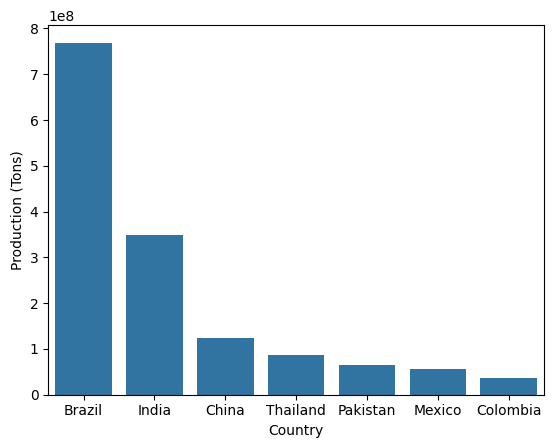

In [35]:
Top_countries = df["Country"].head(7)
Production = df["Production (Tons)"].head(7)
sns.barplot(x = Top_countries , y = Production)
plt.savefig("Production Vs Country")

In [36]:
df.head()

,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,Brazil,South America,768678382.0,3668531.0,10226205.0,751675.0
1,India,Asia,348448000.0,260721.0,4950000.0,703935.0
2,China,Asia,123059739.0,88287.0,1675215.0,734591.0
3,Thailand,Asia,87468496.0,1264303.0,1336575.0,654422.0
4,Pakistan,Asia,65450704.0,324219.0,1130820.0,57879.0


## Distribution of the columns

C:\Users\Asus\AppData\Local\Temp\ipykernel_28312\33938685.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production (Tons)"])
C:\Users\Asus\AppData\Local\Temp\ipykernel_28312\33938685.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production per Person (Kg)"])
C:\Users\Asus\App

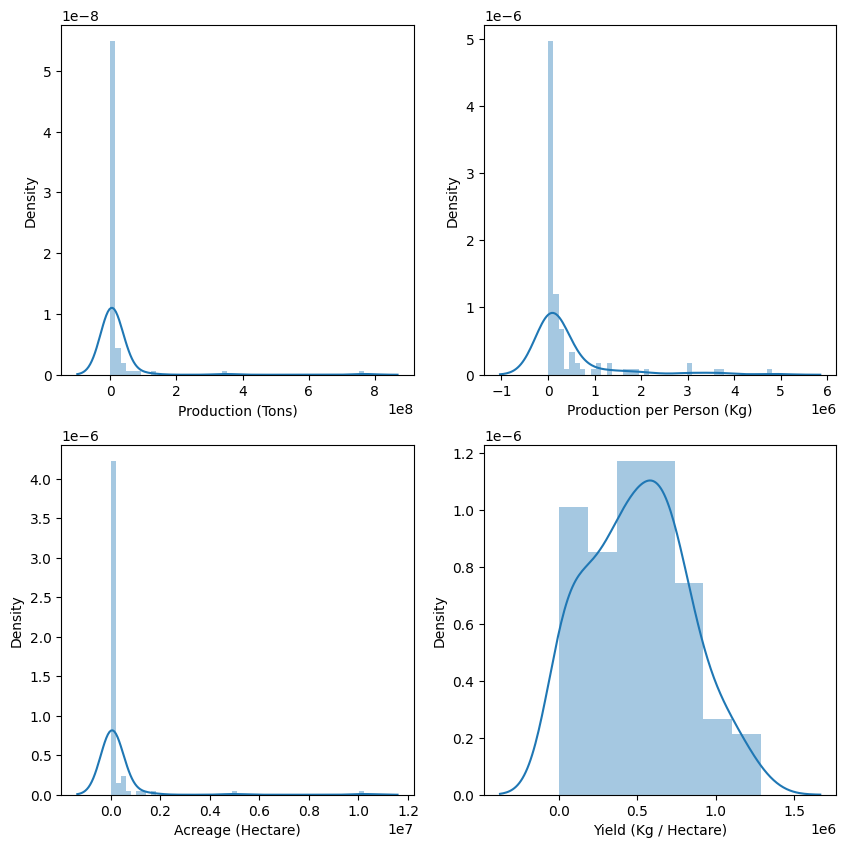

In [37]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production (Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production per Person (Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage (Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield (Kg / Hectare)"])
plt.savefig("Distribution of the columns")

## Checking Outliers

<Axes: ylabel='Yield (Kg / Hectare)'>

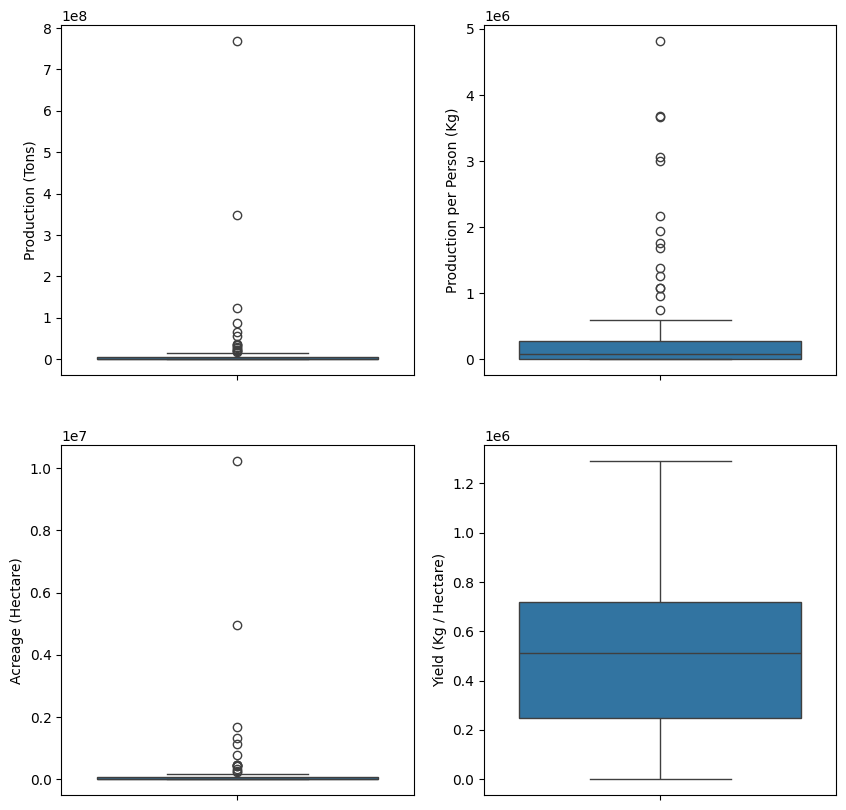

In [38]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production (Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production per Person (Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage (Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield (Kg / Hectare)"])

## Violin Plot

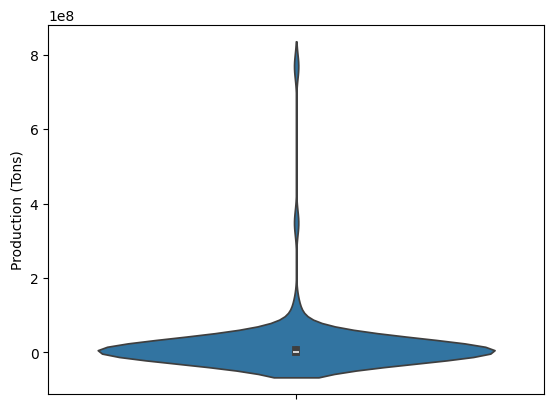

In [39]:
sns.violinplot(df["Production (Tons)"])
plt.savefig("Violin Plot")

C:\Users\Asus\AppData\Local\Temp\ipykernel_28312\39500992.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation =90)


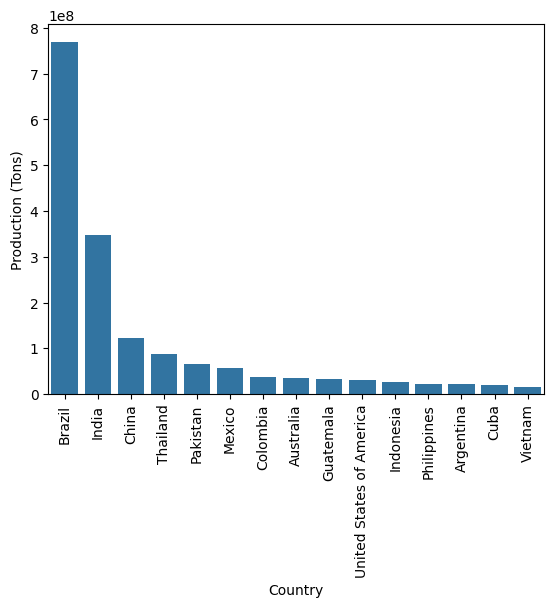

In [40]:
ax = sns.barplot(data = df.head(15),  x = "Country", y = "Production (Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show()

## Correlation

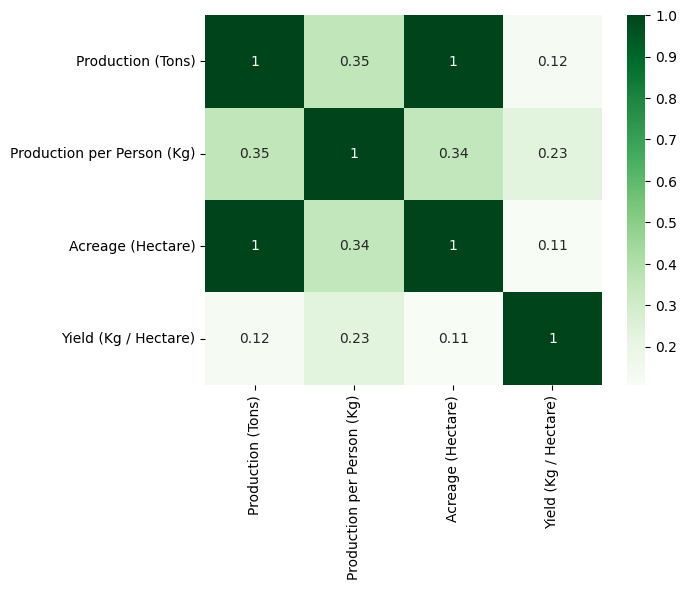

In [41]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap="Greens")
plt.savefig("HeatMap")

## Do countries which yield more sugarcane per hectare produces more sugarcane in total?

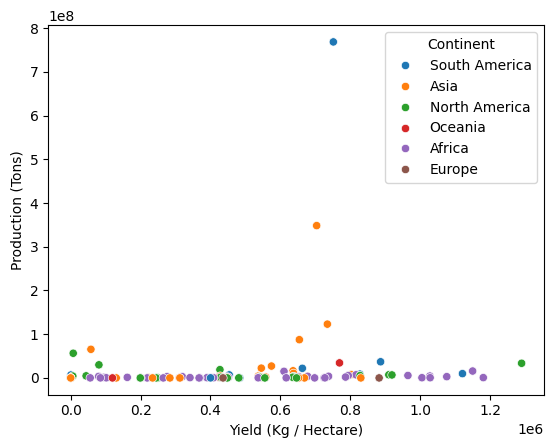

In [42]:
sns.scatterplot(data = df, x = "Yield (Kg / Hectare)" , y = "Production (Tons)", hue = "Continent")
plt.savefig("Scatter Plot")